# 070. Random Forest

## Titanic 호의 생존 예측

필요한 라이브러리를 import 합니다. Random Forest 분류기를 사용하여 타이타닉 생존자를 예측합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

타이타닉 데이터셋을 로드합니다. 이 데이터는 승객의 정보를 바탕으로 생존 여부를 예측하는 문제입니다.

In [2]:
dataset = pd.read_csv("datasets/titanic.csv")

데이터의 처음 5행을 확인하여 데이터 구조를 파악합니다.

In [3]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


모델 학습에 불필요한 컬럼들을 제거합니다. PassengerId, Name, Cabin, Ticket은 생존 예측에 직접적인 영향을 주지 않습니다.

In [4]:
dataset.drop(['PassengerId', 'Name', 
              'Cabin', 'Ticket'], axis=1, inplace=True)

데이터의 기본 정보를 확인합니다. 결측치와 데이터 타입을 확인할 수 있습니다.

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


Age 컬럼의 결측치를 평균값으로 채웁니다. 결측치가 있으면 모델 학습에 문제가 발생할 수 있습니다.

In [6]:
mean_age = dataset['Age'].mean()

dataset['Age'] = dataset['Age'].fillna(mean_age)

범주형 변수를 원-핫 인코딩으로 변환합니다. 예를 들어, Sex 컬럼이 'male', 'female'로 되어 있다면 각각 별도의 컬럼으로 변환됩니다.

In [7]:
dataset.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [8]:
dataset.dropna(inplace=True)

In [9]:
dataset.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [10]:
dataset = pd.get_dummies(dataset)

dataset.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,True,False,False,True


타겟 변수(Survived)와 특성 변수(X)를 분리합니다. Y는 생존 여부(0 또는 1), X는 생존을 예측하기 위한 모든 특성입니다.

In [11]:
Y = dataset['Survived'].values
X = dataset.drop(['Survived'], axis=1).values

데이터를 훈련 세트와 테스트 세트로 분할합니다. test_size=0.2로 80%는 훈련, 20%는 테스트 데이터로 나뉩니다.

In [12]:
# dataset 을 Training 과 Test set 으로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((711, 10), (178, 10), (711,), (178,))

특성 스케일링을 수행합니다. StandardScaler를 사용하여 모든 특성을 평균 0, 표준편차 1로 정규화합니다. 이는 모델의 성능을 향상시킵니다.

In [13]:
# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

Random Forest 분류기를 생성하고 훈련 데이터로 학습시킵니다. n_estimators=10은 10개의 의사결정 트리를 사용한다는 의미입니다.

In [14]:
# Training set 에 대해 Random Forest Classifier model 을 fitting
classifier = RandomForestClassifier(
    n_estimators=300, max_depth=None, random_state=0
)

classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

학습된 Random Forest 모델을 사용하여 테스트 데이터에 대한 예측을 수행하고 정확도를 계산합니다.

In [15]:
y_pred = classifier.predict(X_test)

print(y_pred)
print()
print("Test set true counts = ", sum(y_test))
print("predicted true counts = ", sum(y_pred))
print("accuracy = {:.2f}".format(sum(y_pred == y_test) / len(y_test)))

[1 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 0 1 0 0 1 0 1 0 0 1 0 0 0
 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 1
 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 0 1 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1
 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1]

Test set true counts =  73
predicted true counts =  62
accuracy = 0.77


## confusion matrix 를 이용한 model 평가

혼동 행렬과 평가 지표를 계산하기 위한 라이브러리를 import 합니다.

In [16]:
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.metrics import  accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_predict
import seaborn as sns

혼동 행렬을 계산하고 시각화합니다. 실제 라벨과 예측 라벨의 일치 여부를 확인할 수 있습니다.

confution matrix
 [[47 26]
 [15 90]]


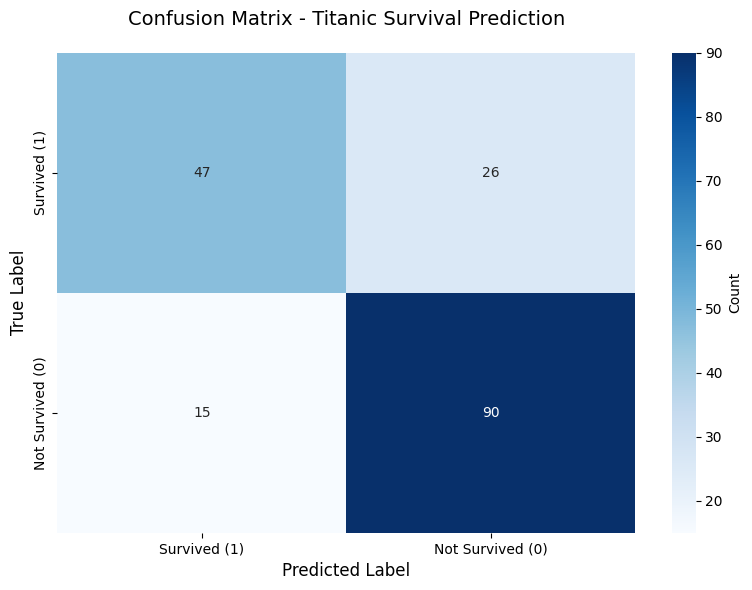

In [17]:
cm  = confusion_matrix(y_test, y_pred, labels=[1, 0])

print("confution matrix\n", cm)

plt.figure(figsize=(8, 6))

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=['Survived (1)', 'Not Survived (0)'],
                 yticklabels=['Survived (1)', 'Not Survived (0)'],
                 cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Titanic Survival Prediction', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

F1 점수를 계산합니다. F1 점수는 정밀도와 재현율의 조화 평균으로, 클래스 불균형이 있을 때 유용한 지표입니다.

In [18]:
print("f1 score : ", f1_score(y_test, y_pred, labels=[1, 0]))

f1 score :  0.6962962962962963
